# Granger Causality: Uncovers potential causal relationships between genes over time. 

Pre-requisites:
- Trained MIOFlow trajectories

In this notebook:
- Perform Granger causality testing:
    - Between each pair of genes (or a subset of input/output gene groups).

    - Using lag-1 autoregressive models.

- Output a p-value matrix:

    - Rows: Response genes

    - Columns: Predictor genes

    - Values: Significance of Granger-causal influence

In [12]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import pickle
import warnings
from statsmodels.tsa.stattools import grangercausalitytests
import scanpy as sc
from joblib import Parallel, delayed
import os
import torch
import networkx as nx
import dgl
import re

import matplotlib.pyplot as plt
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

seed = 3
torch.manual_seed(seed)
np.random.seed(seed)
lag_order = 1 # since we aggregated the data in to 9 bins we only need 1 lag
maxlag = (
    lag_order,  # becuase we got this value before. We are not suppose to add 1 to it
)

RAW_DATA_DIR = os.path.join('../../data', 'raw')
PROCESSED_DATA_DIR = os.path.join('../../data', 'processed')
RESULTS_DIR = os.path.join('../../results')

data_name = 'scRNAseq'
SAVE_PATH = os.path.join(RESULTS_DIR, data_name)

adata = sc.read(os.path.join(PROCESSED_DATA_DIR, 'adata_mioflow.h5ad'))
gene_names = adata.var_names

traj = np.load(os.path.join(SAVE_PATH,'trajectories_gene_space.npy'))

test = "ssr_chi2test"


In [13]:
def grangers_causation_matrix(
    data, in_variables, out_variables, test="ssr_chi2test", n_jobs=1, warn=False
):
    """Check Granger Causality of all possible combinations of the Time series.
    The rows are the response variable, columns are predictors. The values in the table 
    are the P-Values. P-Values lesser than the significance level (0.05), implies 
    the Null Hypothesis that the coefficients of the corresponding past values is 
    zero, that is, the X does not cause Y can be rejected.

    data      : pandas dataframe containing the time series variables
    variables : list containing names of the time series variables.
    """

    def get_pval(dd):
        if warn:
            test_result = grangercausalitytests(dd, maxlag=maxlag, verbose=True)
        else:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=FutureWarning)
                test_result = grangercausalitytests(dd, maxlag=maxlag, verbose=False)
                # according to the documentation https://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.grangercausalitytests.html,
                # the dd has 2 columns, second causes the first.

        p_values = [test_result[i][0][test][1] for i in maxlag] # test_result[i][1] is the unrestricted model, test_result[i][1][0] is the restricted model
        coefs = [test_result[i][1][1].params[1] for i in maxlag] # x1, x2, const

        arg_min_p_value = np.argmin(p_values)
        min_p_value = p_values[arg_min_p_value]
        min_coef = coefs[arg_min_p_value]
        return (min_p_value, min_coef)

    out = Parallel(n_jobs=n_jobs)(
        delayed(get_pval)(data[[c, r]]) # this means r causes c, so r is be in and c is out
        for c in tqdm(out_variables, desc="Processing columns")  # Outer loop progress bar
        for r in in_variables  # Inner loop without progress bar
    )
    out_p = [p for (p,c) in out]
    out_c = [c for (p,c) in out]
    df_p = pd.DataFrame(
        np.array(out_p).reshape((len(out_variables), len(in_variables))), # should be reshaped to len(out_variables), len(in_variables) according to the for loop.
        columns=in_variables,
        index=out_variables,
    ).T # used the correct reshaping, and then transposed the matrix so the x and y are semantically correct (x causes y).
    df_c = pd.DataFrame(
        np.array(out_c).reshape((len(out_variables), len(in_variables))), # should be reshaped to len(out_variables), len(in_variables) according to the for loop.
        columns=in_variables,
        index=out_variables,
    ).T
    df_p.index = [var + "_x" for var in in_variables]
    df_p.columns = [var + "_y" for var in out_variables]
    df_c.index = [var + "_x" for var in in_variables]
    df_c.columns = [var + "_y" for var in out_variables]
    return df_p, df_c

def do_granger(trajs, in_genes, out_genes, n_jobs=1, warn=False):
    # in causes out
    trajs = trajs.T[::10]
    trajs = trajs - trajs.shift(1)
    trajs = trajs.dropna()
    out_traj_p, out_traj_c = grangers_causation_matrix(
        trajs, in_variables=in_genes, out_variables=out_genes, n_jobs=n_jobs, warn=warn
    )
    return out_traj_p, out_traj_c

Load the gene expression trajectories generated by MIOFlow along with the original dataset. For simplicity, we focus on the top 2,000 most highly variable genes.

In [ ]:
trajectories = np.load('../../results/scRNAseq/trajectories_gene_space.npy', allow_pickle=True)
adata = sc.read('../../data/processed/adata_mioflow.h5ad')
genes = adata.var_names.to_list()
sc.pp.highly_variable_genes(adata, n_top_genes=20)
hv_mask = adata.var['highly_variable']
genes_hvg = hv_mask[hv_mask].index.tolist()
col_genes = np.array(genes_hvg)

In [14]:
with open('../../data/processed/trajectories_gene_space.pkl', 'rb') as f:
    trajectories = pickle.load(f)

with open('../../data/processed/gene_names_array.pkl', 'rb') as f:
    genes = pickle.load(f)

adata = sc.read('../../data/processed/final_adata.h5ad')
sc.pp.highly_variable_genes(adata, n_top_genes=20)
hv_mask = adata.var['highly_variable']
genes_hvg = hv_mask[hv_mask].index.tolist()
col_genes = np.array(genes_hvg)

In [15]:
trajectories.shape

(100, 100, 21465)

Intersect the selected genes with the list of human transcription factors downloaded from humantfs.ccbr.utoronto.ca to identify the input genes that are transcription factors.

In [16]:
db_extract = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, 'DatabaseExtract_v_1.01.csv'))
db_ensembl_ids = set(db_extract['HGNC symbol'].astype(str))
genes_ensembl_ids = set([g.split('(')[-1].replace(')', '').strip() for g in genes_hvg])
in_genes_ensembl = genes_ensembl_ids & db_ensembl_ids
in_genes = [g for g in genes_hvg if g.split('(')[-1].replace(')', '').strip() in in_genes_ensembl]

In [17]:
trajectories_hvg = trajectories[:, :, hv_mask.values]
avg_traj = trajectories_hvg.mean(axis=1)
trajectories_df = pd.DataFrame(avg_traj, columns=col_genes)
out_traj_p, out_traj_c = do_granger(trajectories_df.T, in_genes, genes_hvg, n_jobs=1, warn=False)

Processing columns: 100%|██████████| 20/20 [00:00<00:00, 359.45it/s]


Output of Granger Causality:

1. out_traj_p: p-value (smaller the better)
2. out_traj_c: coefficient (the sign indicates if it is up or down regulation)

# Constructing the Prior Graph

Now we take the Granger causality p-values, convert them to -log(p) scores, filter out insignificant values using a threshold, and prepare the resulting matrix (preds) for building the prior graph.

In [30]:
"""
Load Granger causality data to construct the prior graph.
"""
granger_df_all_T = out_traj_p
epsilon = 1e-10
threshold = 0.6  # You can adjust this value as needed

neg_log_p = -np.log(granger_df_all_T + epsilon)
granger_df_all_T = neg_log_p.where(neg_log_p > threshold, 0)

preds = granger_df_all_T.to_numpy()
tf_count = preds.shape[0]

In [31]:
# --- Set up labels (gene names) ---
top_genes = list(granger_df_all_T.columns)  # output genes
in_genes = list(granger_df_all_T.index)     # input genes (TFs)

# Extract the part before the space (i.e., the gene symbol)
clean_top_genes = [re.sub(r'\s+\(.*?\)_y$', '', h) for h in top_genes]
top_genes = clean_top_genes
# --- Create directed NetworkX graph ---
G = nx.DiGraph()

# Add nodes (we'll use all output genes as node set)
for idx, gene in enumerate(top_genes):
    G.add_node(idx, label=gene)

# Add edges: r (input gene) -> c (output gene) if significant
for i, input_gene in enumerate(in_genes):
    for j, output_gene in enumerate(top_genes):
        if preds[i, j] >= threshold:
            G.add_edge(i, j)  # node indices match column indices of `top_genes`

# --- Convert NetworkX to DGL ---
edges = list(G.edges())
if len(edges) > 0:
    u, v = np.array(edges).T
    u = torch.tensor(u, dtype=torch.int32)
    v = torch.tensor(v, dtype=torch.int32)
else:
    u = v = torch.tensor([], dtype=torch.int32)

g = dgl.graph((u, v))

# Add dummy node features (e.g., 1D ones)
g.ndata['feat'] = torch.ones((g.number_of_nodes(), 1))

# --- For plotting ---
ref_g = g.to_networkx()
ref_pos = nx.spring_layout(ref_g.to_undirected(), seed=seed)

# Color and label
for idx, node in enumerate(ref_g.nodes()):
    ref_g.nodes[node]['color'] = plt.get_cmap('viridis', len(top_genes))(idx)
    ref_g.nodes[node]['label'] = top_genes[idx]

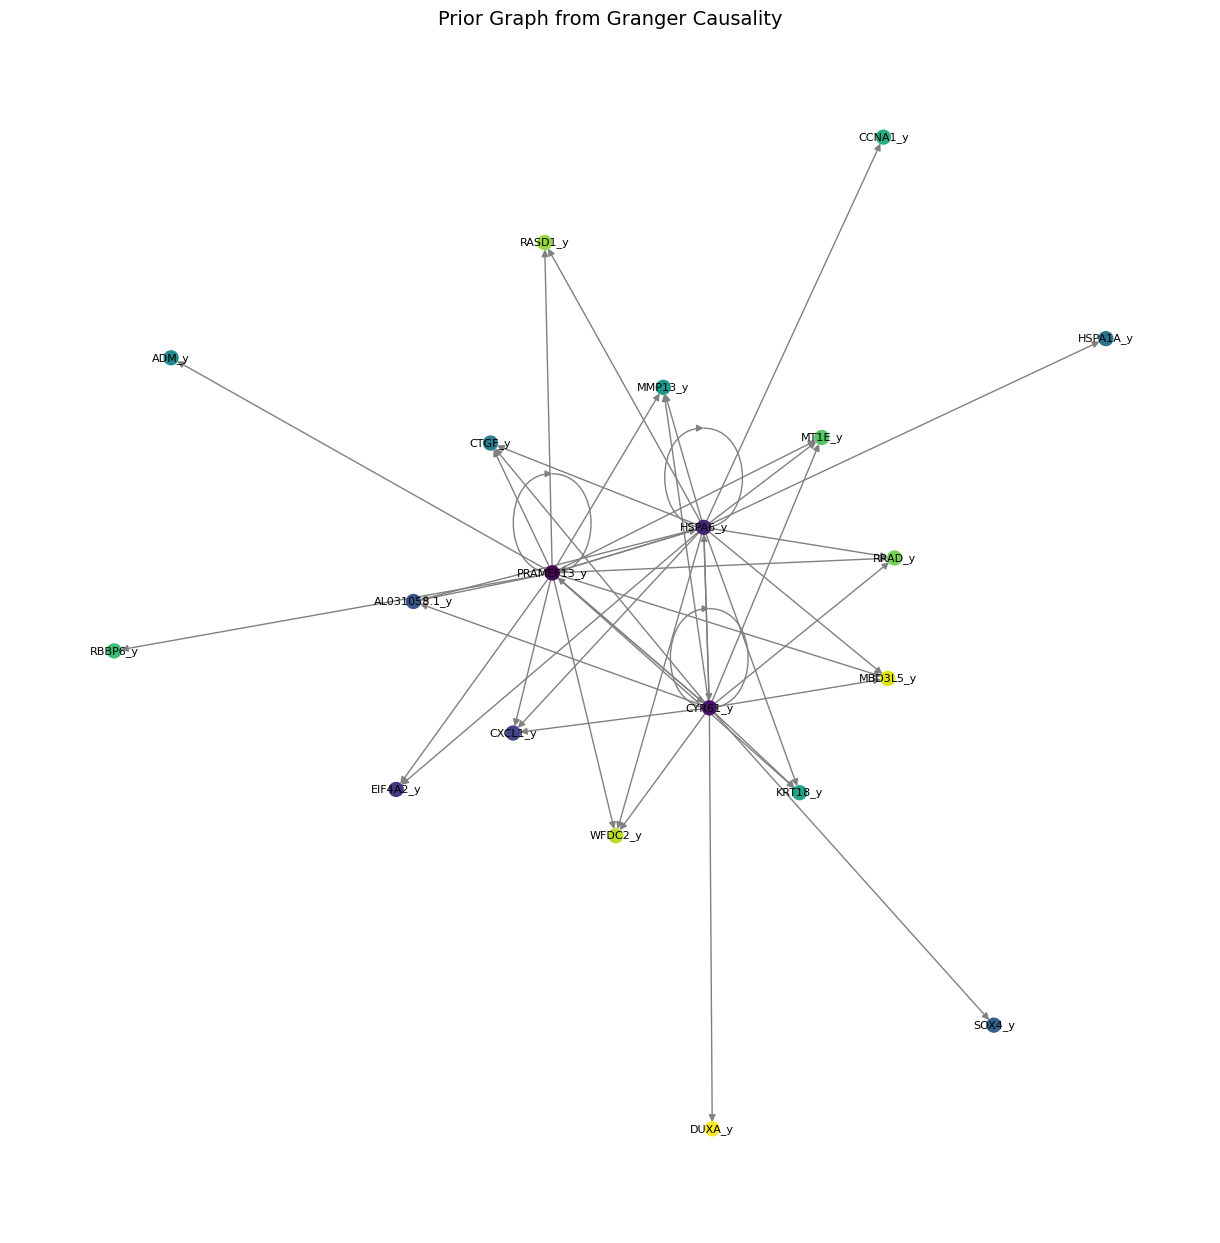

In [32]:
# Set figure size
plt.figure(figsize=(12, 12))

# Extract node colors and labels
node_colors = [ref_g.nodes[n]['color'] for n in ref_g.nodes()]
node_labels = {n: ref_g.nodes[n]['label'] for n in ref_g.nodes()}

# Draw the graph
nx.draw(
    ref_g,
    pos=ref_pos,
    with_labels=False,
    node_color=node_colors,
    edge_color='gray',
    arrows=True,
    node_size=100
)

# Draw node labels separately for clarity
nx.draw_networkx_labels(ref_g, pos=ref_pos, labels=node_labels, font_size=8)

plt.title("Prior Graph from Granger Causality", fontsize=14)
plt.axis('off')
plt.show()

Save the graphs for downstream use in RiTINI training and evaluation.

In [33]:
# Save top_genes (output genes) as a pickle file
with open(os.path.join(PROCESSED_DATA_DIR, 'cancer_granger_prior_top_genes_20.pkl'), 'wb') as f:
    pickle.dump(top_genes, f)
    
# Save NetworkX graph G
with open(os.path.join(PROCESSED_DATA_DIR, 'cancer_granger_prior_graph_nx_20.pkl'), 'wb') as f:
    pickle.dump(G, f)

# Optionally, save DGL graph as pickle (note: this is not the recommended way for DGL, but works for simple use cases)
with open(os.path.join(PROCESSED_DATA_DIR, 'cancer_granger_prior_graph_dgl_20.pkl'), 'wb') as f:
    pickle.dump(g, f)

In [12]:
from collections import defaultdict

def read_graphs(filename):
    """
    Read two graphs from a file and return as adjacency lists.
    
    File format:
        n m
        (m lines of edges for G)
        (m lines of edges for G')
    Vertices are assumed to be labeled 1..n.
    
    Returns:
        n: number of vertices
        adj_G: adjacency list for G (dict: vertex -> set of neighbors)
        adj_G_prime: adjacency list for G' (dict: vertex -> set of neighbors)
    """
    with open(filename, 'r') as f:
        n, m = map(int, f.readline().split())
        
        adj_G = defaultdict(set)
        adj_G_prime = defaultdict(set)
        
        # Read edges for G
        for _ in range(m):
            u, v = map(int, f.readline().split())
            adj_G[u].add(v)
            adj_G[v].add(u)  # undirected
        
        # Read edges for G'
        for _ in range(m):
            u, v = map(int, f.readline().split())
            adj_G_prime[u].add(v)
            adj_G_prime[v].add(u)  # undirected
    
    # Make sure all vertices 1..n appear in the dicts (even isolated ones)
    for v in range(1, n + 1):
        _ = adj_G[v]
        _ = adj_G_prime[v]
    
    return n, adj_G, adj_G_prime

def count_edges(adj):
    """Return number of undirected edges given an adjacency dict."""
    return sum(len(neighs) for neighs in adj.values()) // 2

def initial_bijection_by_degree(n, G, G_prime):
    """
    Construct an initial bijection f: V -> V' by sorting vertices by degree.
    Returns a dict mapping vertex in G to vertex in G'.
    """
    vertices = list(range(1, n + 1))
    
    # Degrees in each graph
    deg_G = {v: len(G[v]) for v in vertices}
    deg_Gp = {v: len(G_prime[v]) for v in vertices}
    
    # Sort vertices by degree (descending), tie-break by vertex id
    V_sorted = sorted(vertices, key=lambda v: (deg_G[v], v), reverse=True)
    Vp_sorted = sorted(vertices, key=lambda v: (deg_Gp[v], v), reverse=True)
    
    # Initial bijection: match k-th vertex in G's sorted list
    # to k-th vertex in G' sorted list
    f = {}
    for v, vp in zip(V_sorted, Vp_sorted):
        f[v] = vp
    
    return f

def compute_score(mapping, G, G_prime, m):
    """
    Compute x = (# of edges (u,v) in E such that (f(u), f(v)) in E') / m
    for undirected graphs, counting each undirected edge once.
    """
    preserved = 0
    # To avoid double counting, only count edges with u < v
    for u in G:
        for v in G[u]:
            if u < v:
                fu = mapping[u]
                fv = mapping[v]
                # Check if (fu, fv) is an edge in G'
                if fv in G_prime[fu]:
                    preserved += 1
    x = preserved / m if m > 0 else 0.0
    return x, preserved

def hill_climb_matching(n, G, G_prime, max_passes=100):
    """
    Hill-climbing over bijections f: V -> V'.
    Neighborhood move: swap the images of two vertices in V.
    
    Returns:
        best_mapping: dict v -> v'
        best_score: x(f)
        best_preserved: count of preserved edges
    """
    vertices = list(range(1, n + 1))
    
    # Number of edges in G (and G') – should both be m
    m = count_edges(G)
    
    # Initial bijection f_0
    mapping = initial_bijection_by_degree(n, G, G_prime)
    best_score, best_preserved = compute_score(mapping, G, G_prime, m)
    
    improved = True
    passes = 0
    
    while improved and passes < max_passes:
        improved = False
        passes += 1
        
        # Try all pairs (a, b); stop as soon as we find an improvement
        for i in range(n):
            if improved:
                break
            for j in range(i + 1, n):
                a = vertices[i]
                b = vertices[j]
                
                # Create swapped mapping
                new_mapping = mapping.copy()
                new_mapping[a], new_mapping[b] = new_mapping[b], new_mapping[a]
                
                new_score, new_preserved = compute_score(new_mapping, G, G_prime, m)
                
                if new_score > best_score:
                    mapping = new_mapping
                    best_score = new_score
                    best_preserved = new_preserved
                    improved = True
                    break  # break inner loop, restart search with new mapping
    
    return mapping, best_score, best_preserved, m

def main():
    n, G, G_prime = read_graphs('graphs')
    mapping, score, preserved, m = hill_climb_matching(n, G, G_prime)
    
    print("Best score x(f) = preserved_edges / m = {}/{} = {:.4f}".format(
        preserved, m, score
    ))
    print("Mapping f (vertex in G -> vertex in G'):")
    for v in range(1, n + 1):
        print(f"{v} -> {mapping[v]}")

if __name__ == "__main__":
    main()


FileNotFoundError: [Errno 2] No such file or directory: 'graphs'